image            : ./data/train_images/L1000770.jpg
dimensions       : 4000 x 2662 px
tile size        : 75 x 75 px
overlap / stride : 0.6667 -> 25 px
grid             : 158 cols x 105 rows = 16590 tiles
mask thresholds  : S < 40, V > 180 flagged as background
discard threshold: mean whiteness < 25.5 (= 10% of 255)
kept / discarded : 2244 kept, 14346 discarded
tiles saved to   : ./tiles/tiles/  (source: original)

wrote:
  ./tiles/L1000770_mask.png
  ./tiles/L1000770_tiling.png
  ./tiles/L1000770_samples.png
  ./tiles/L1000770_sample_map.png
  ./tiles/tiles/  (2244 tile images)

Done. Kept 2244 / 16590 tiles (14346 discarded as background).


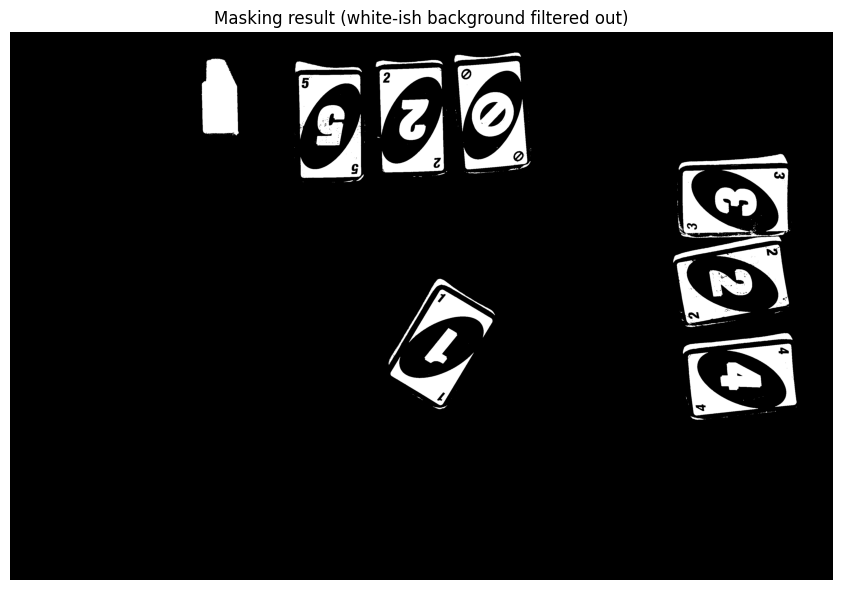

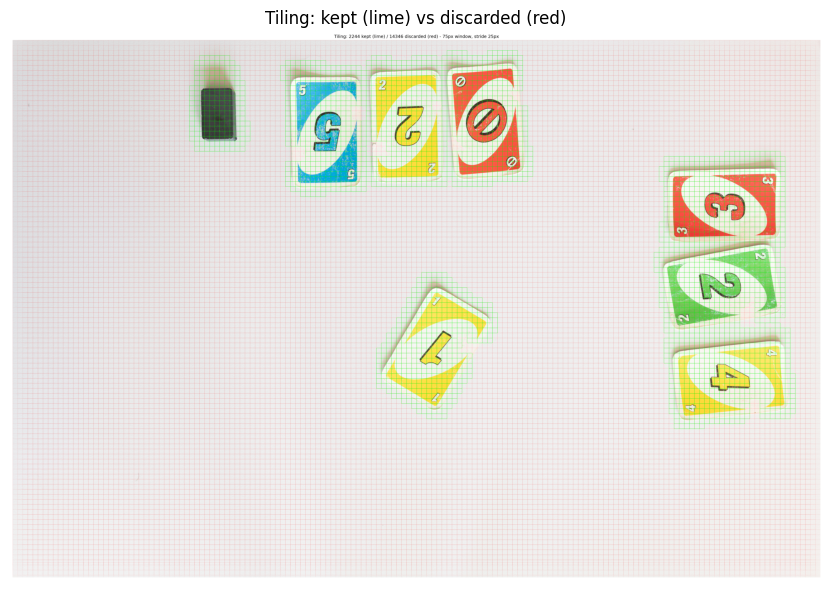

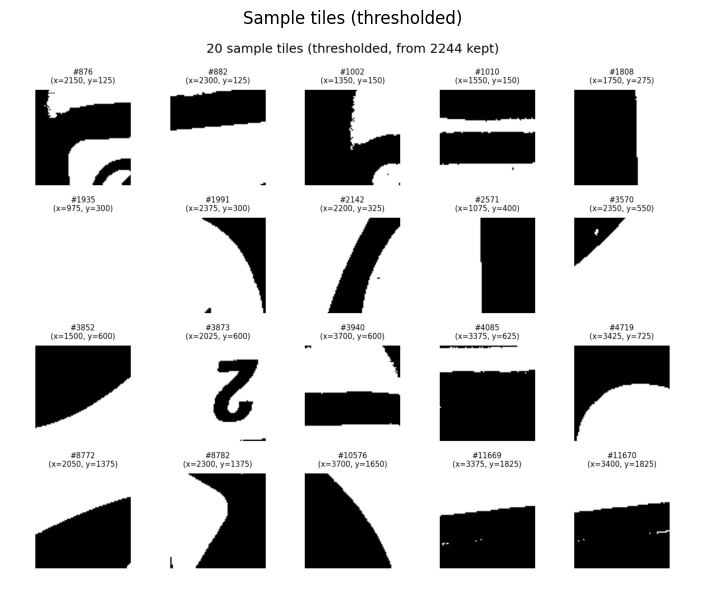

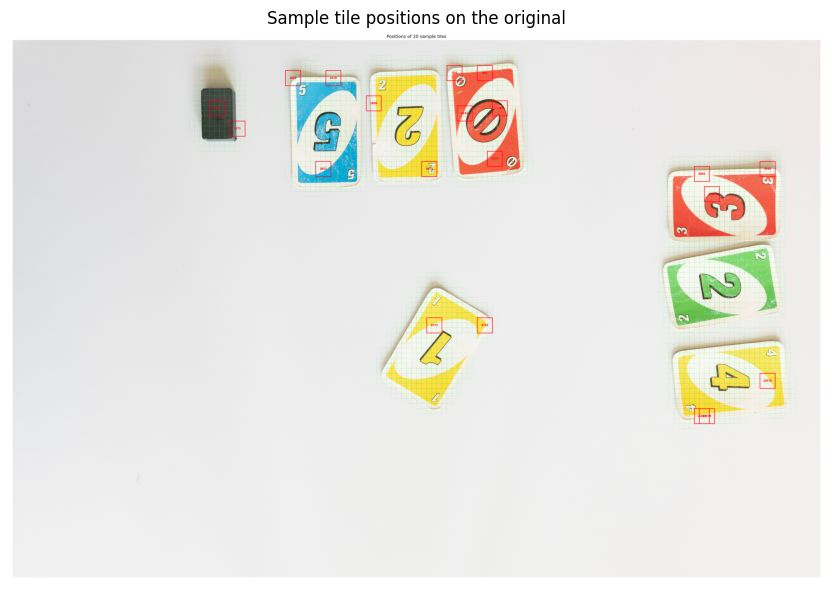

In [1]:
#!/usr/bin/env python3
"""
main.py
=======
Entry point for the UNO card tiling pipeline.
Configure the parameters below, then run:  python main.py
"""

# ---- imports ----
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tiling import tile_image

# ---- default window and convolution params ----
TILE_SIZE = 75            # square convolution window size, in px
OVERLAP   = 2.0 / 3.0     # fractional overlap -> stride = round(TILE_SIZE * (1 - OVERLAP))

# ---- default threshold params ----
SAT_MAX             = 40    # HSV saturation below this -> candidate white-ish background
VAL_MIN             = 180   # HSV value above this      -> candidate white-ish background
WHITENESS_KEEP_FRAC = 0.10  # keep a tile only if its mean whiteness >= 10% of 255

# ---- sampling / output params ----
N_SAMPLES   = 20          # how many kept tiles to show in the sample montage
SEED        = 42          # RNG seed for reproducible sampling
SAVE_SOURCE = "original"  # "original" = save RGB crops, "masked" = save mask crops

# ---- path to image ----
#IMAGE_PATH = "./data/reference_images/L1000765.jpg"
IMAGE_PATH = "./data/train_images/L1000770.jpg"
OUTDIR     = "./tiles/"   # set to None to write next to the image

# ---- call the tiling function on image ----
if __name__ == "__main__":
    results = tile_image(
        image_path=IMAGE_PATH,
        tile_size=TILE_SIZE,
        overlap=OVERLAP,
        sat_max=SAT_MAX,
        val_min=VAL_MIN,
        whiteness_keep_frac=WHITENESS_KEEP_FRAC,
        n_samples=N_SAMPLES,
        seed=SEED,
        outdir=OUTDIR,
        save_source=SAVE_SOURCE,
    )

    print(f"\nDone. Kept {results['n_kept']} / {results['n_tiles']} tiles "
          f"({results['n_discarded']} discarded as background).")

    # ---- display: masking result + the three tiling outputs ----
    def show(path, title, cmap=None):
        img = mpimg.imread(path)
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
        fig.tight_layout()

    # result from the masking process
    show(results["mask_path"], "Masking result (white-ish background filtered out)",
         cmap="gray")
    # the three tiling outputs
    show(results["grid_path"], "Tiling: kept (lime) vs discarded (red)")
    show(results["samples_path"], "Sample tiles (thresholded)")
    show(results["map_path"], "Sample tile positions on the original")

    plt.show()